# Exploratory Data Analysis — KOI Cumulative Table

This notebook explores the Kepler Objects of Interest (KOI) cumulative
table before any preprocessing or modeling decisions are made. The goal is
to understand the target variable, identify missing data, spot leakage-prone
columns, and get a sense of the core physical features available.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 20)

df = pd.read_csv('../data/raw/koi_cumulative.csv', comment='#')
df.shape

(9564, 153)

## Target Variable

`koi_disposition` is the label we want to predict: whether a KOI is a
confirmed exoplanet, a candidate, or a false positive.

In [2]:
df['koi_disposition'].value_counts()

koi_disposition
FALSE POSITIVE    4839
CONFIRMED         2747
CANDIDATE         1978
Name: count, dtype: int64

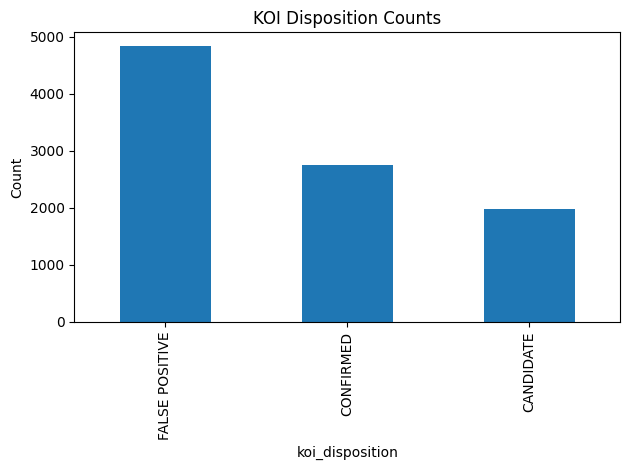

In [3]:
df['koi_disposition'].value_counts().plot(kind='bar', title='KOI Disposition Counts')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

The classes are imbalanced but not severely so — false positives are
roughly 2.4x more common than candidates. This is manageable without
resampling, but worth keeping in mind when evaluating the model (accuracy
alone won't tell the full story; per-class precision/recall will matter).

## Missing Data

The raw table has 153 columns. Many of them are uncertainty/error columns
or fields that aren't populated in this archive snapshot at all.

In [4]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
fully_empty = missing_pct[missing_pct == 100]
print(f"Columns that are 100% missing: {len(fully_empty)}")
missing_pct.head(15)

Columns that are 100% missing: 24


koi_gmag_err        100.0
koi_imag_err        100.0
koi_zmag_err        100.0
koi_rmag_err        100.0
koi_kepmag_err      100.0
koi_longp_err2      100.0
koi_sage_err2       100.0
koi_sage_err1       100.0
koi_sage            100.0
koi_sma_err1        100.0
koi_sma_err2        100.0
koi_ingress_err1    100.0
koi_ingress         100.0
koi_ingress_err2    100.0
koi_incl_err2       100.0
dtype: float64

24 columns are completely empty and can be dropped outright — they
carry no information. Beyond those, most columns have low missingness
(under 5%), which means rows with missing values can likely just be
dropped rather than needing imputation.

## Leakage-Prone Columns

Two columns look suspicious because they may already encode the answer
we're trying to predict:

- `koi_pdisposition` — the Kepler pipeline's own automated disposition
- `koi_score` — the pipeline's own confidence score for that disposition

In [5]:
pd.crosstab(df['koi_pdisposition'], df['koi_disposition'])

koi_disposition,CANDIDATE,CONFIRMED,FALSE POSITIVE
koi_pdisposition,,,
CANDIDATE,1978,2738,1
FALSE POSITIVE,0,9,4838


In [6]:
df.groupby('koi_disposition')['koi_score'].describe()

,count,mean,std,min,25%,50%,75%,max
koi_disposition,,,,,,,,
CANDIDATE,1378.0,0.798436,0.310737,0.0,0.76025,0.965,0.998,1.0
CONFIRMED,2730.0,0.960437,0.146904,0.0,0.99125,1.000,1.000,1.0
FALSE POSITIVE,3946.0,0.038105,0.158799,0.0,0.00000,0.000,0.000,1.0


Both columns are almost perfect proxies for the target: `koi_score`
averages 0.96 for confirmed planets and 0.04 for false positives, and
`koi_pdisposition` matches `koi_disposition` in the vast majority of rows.
**These columns must be excluded from model features** — including them
would let the model "cheat" by copying an existing classification instead
of learning from the underlying physical measurements.

## Core Physical Features

These are the measurements astronomers actually use to characterize a
transit signal and its host star: orbital period, transit depth/duration,
planet radius, equilibrium temperature, stellar properties, and the
model's transit signal-to-noise ratio.

In [7]:
core_features = [
    'koi_period', 'koi_duration', 'koi_depth', 'koi_prad', 'koi_teq',
    'koi_insol', 'koi_model_snr', 'koi_steff', 'koi_slogg', 'koi_srad',
    'koi_kepmag', 'koi_impact',
]

df[core_features].isna().mean().mul(100).round(2)

koi_period       0.00
koi_duration     0.00
koi_depth        3.80
koi_prad         3.80
koi_teq          3.80
koi_insol        3.36
koi_model_snr    3.80
koi_steff        3.80
koi_slogg        3.80
koi_srad         3.80
koi_kepmag       0.01
koi_impact       3.80
dtype: float64

In [8]:
df[core_features].describe().T[['mean', 'std', 'min', 'max']]

,mean,std,min,max
koi_period,75.671358,1334.744046,0.241843,1.299958e+05
koi_duration,5.621606,6.471554,0.052000,1.385400e+02
koi_depth,23791.343984,82242.684708,0.000000,1.541400e+06
koi_prad,102.891778,3077.639126,0.080000,2.003460e+05
koi_teq,1085.385828,856.351161,25.000000,1.466700e+04
koi_insol,7745.737023,159204.665200,0.000000,1.094755e+07
koi_model_snr,259.895001,795.806615,0.000000,9.054700e+03
koi_steff,5706.823280,796.857947,2661.000000,1.589600e+04
koi_slogg,4.310157,0.432606,0.047000,5.364000e+00
koi_srad,1.728712,6.127185,0.109000,2.299080e+02


Missingness for these features sits around 3.8%, confirming that
dropping incomplete rows is a reasonable, simple strategy. The wide gap
between `mean` and `max` for columns like `koi_period` and `koi_prad`
signals heavy-tailed distributions with extreme outliers — likely
misclassified or noisy false-positive signals rather than real planets.
A log transform may help these features during modeling.

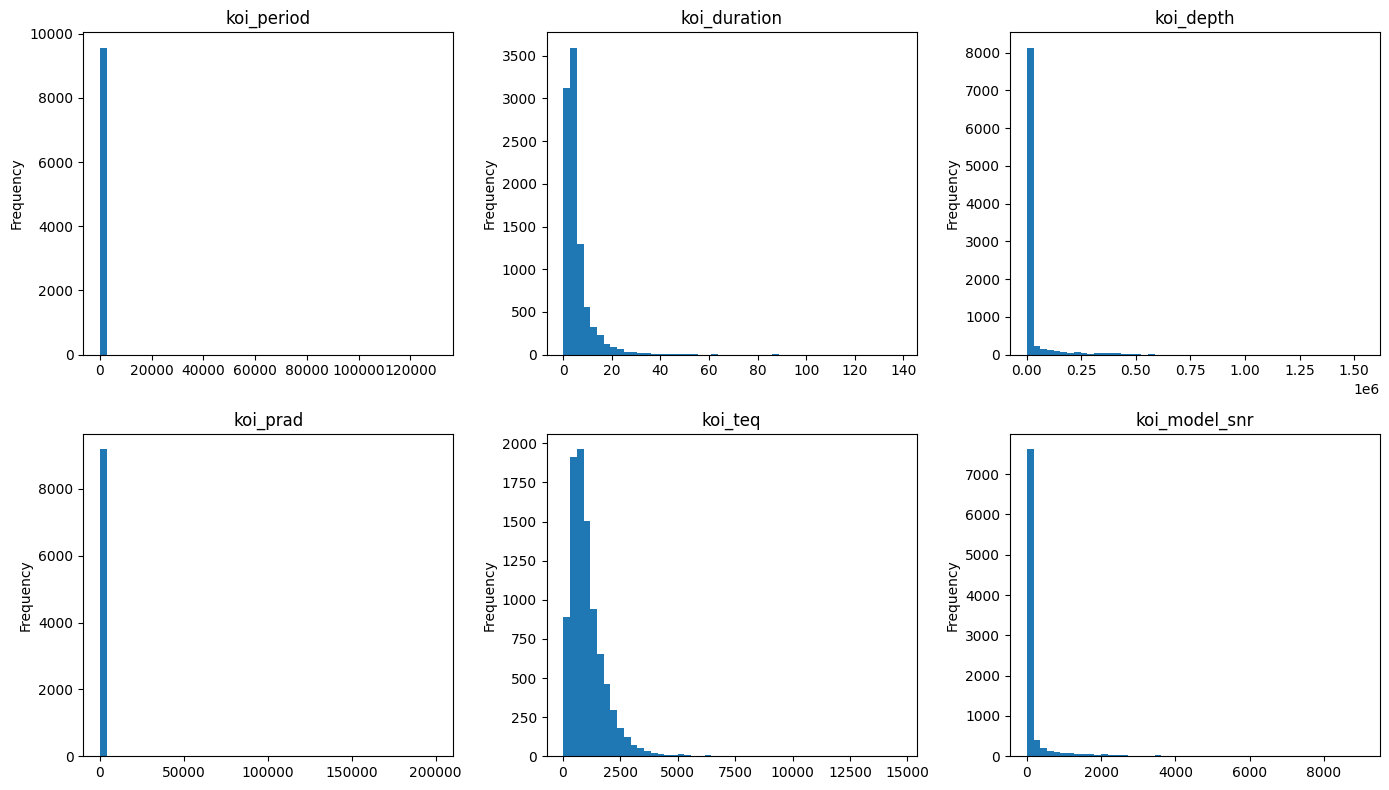

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
plot_features = ['koi_period', 'koi_duration', 'koi_depth', 'koi_prad', 'koi_teq', 'koi_model_snr']

for ax, feature in zip(axes.flat, plot_features):
    df[feature].dropna().plot(kind='hist', bins=50, ax=ax, title=feature)

plt.tight_layout()
plt.show()

Most of these distributions are right-skewed with a long tail of
extreme values, confirming what the `describe()` output suggested.

## Correlation Among Core Features

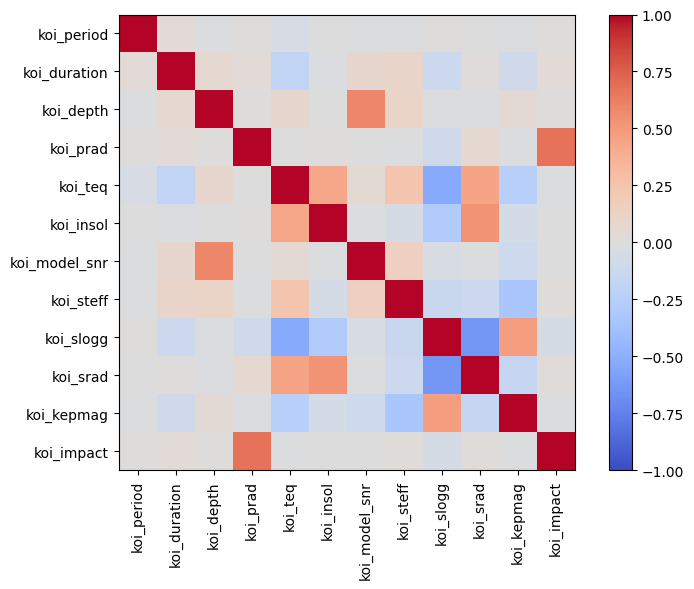

In [10]:
correlation = df[core_features].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(correlation, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(core_features)))
ax.set_yticks(range(len(core_features)))
ax.set_xticklabels(core_features, rotation=90)
ax.set_yticklabels(core_features)
fig.colorbar(im)
plt.tight_layout()
plt.show()

No pair of core features is strongly correlated, so there's no
obvious redundancy to remove at this stage.

## Summary of Findings

- The target (`koi_disposition`) has 3 classes with a moderate imbalance;
  no resampling needed, but per-class metrics should be reported.
- 24 columns are 100% empty and should be dropped.
- `koi_pdisposition` and `koi_score` leak the target and must be excluded
  from model features.
- 12 core physical features have low missingness (~3.8%) — dropping
  incomplete rows is simpler than imputing and should be fine here.
- Several core features are heavily right-skewed with outliers; a log
  transform is worth testing during preprocessing.
- No strong pairwise correlation among core features, so no immediate
  need for dimensionality reduction.

These findings directly inform the preprocessing pipeline in the next
phase.